In [9]:
import numpy as np

import matplotlib.pyplot as plt

import ipywidgets
from ipywidgets import interact

# 练习二：线性判别分析

## 生成简单数据集

In [25]:
# 固定随机数种子
np.random.seed(2025)

# 从二元正态分布中采样第 0 类样本
x_0_sample = np.random.multivariate_normal(
    mean=np.array([1.0, 2.0]),
    cov=np.array([[0.5,-0.25],[-0.25, 0.5]]),
    size=30,
)

# 从二元正态分布中采样第 1 类样本
x_1_sample = np.random.multivariate_normal(
    mean=np.array([4.0, 3.0]),
    cov=np.array([[0.5,-0.25],[-0.25, 0.5]]),
    size=30,
)

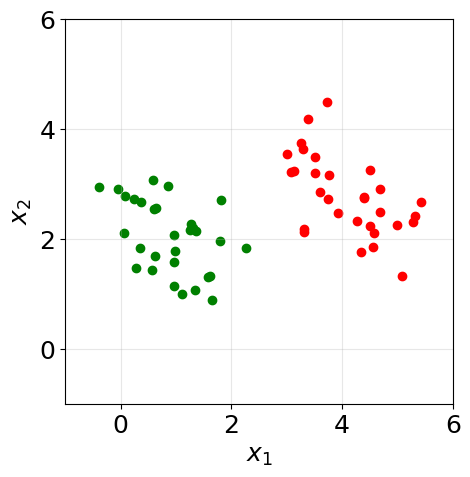

In [35]:
# 可视化数据集

# 创建画布
plt.figure(figsize=(5, 5))

# 绘制样本点
plt.scatter(x_0_sample[:, 0], x_0_sample[:, 1], color="g")
plt.scatter(x_1_sample[:, 0], x_1_sample[:, 1], color="r")

# 美化细节
plt.grid(alpha=0.3)
plt.tick_params(labelsize=18)
plt.xlabel("$x_1$", size=18)
plt.ylabel("$x_2$", size=18)
plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.xticks([0, 2, 4, 6])
plt.yticks([0, 2, 4, 6])
plt.show()

## 计算样本均值向量和样本协方差矩阵

In [44]:
mu_0 = np.mean(x_0_sample, axis=0)
sigma_0 = np.cov(x_0_sample.T, bias=False) # 无偏估计：分母是 (N-1)

mu_1 = np.mean(x_1_sample, axis=0)
sigma_1 = np.cov(x_1_sample.T, bias=False) # 无偏估计：分母是 (N-1)

print(f"{mu_0 = }")
print(f"{sigma_0 = }")
print()
print(f"{mu_1 = }")
print(f"{sigma_1 = }")

mu_0 = array([0.90252854, 2.03710846])
sigma_0 = array([[ 0.40662956, -0.18690372],
       [-0.18690372,  0.42533495]])

mu_1 = array([4.08624502, 2.78565473])
sigma_1 = array([[ 0.54299013, -0.30740938],
       [-0.30740938,  0.52415913]])


## 在向量 $w$ 上的投影结果

In [80]:
# 向量 w 用于指定方向，其大小并不重要，因此选择单位向量
w = np.array([np.cos(np.pi/6), np.sin(np.pi/6)])

# 计算投影后的结果

z_0 = np.einsum("i,ji->j", w, x_0_sample)
z_0 = np.einsum("i,j->ij", z_0, w)

z_1 = np.einsum("i,ji->j", w, x_1_sample)
z_1 = np.einsum("i,j->ij", z_1, w)

# 计算目标函数值
S_b = np.outer(mu_0 - mu_1, mu_0 - mu_1)
S_w = sigma_0 + sigma_1
J = np.dot(w, S_b @ w) / np.dot(w, S_w @ w)
print(f"{J = }")

J = 18.803420238375246


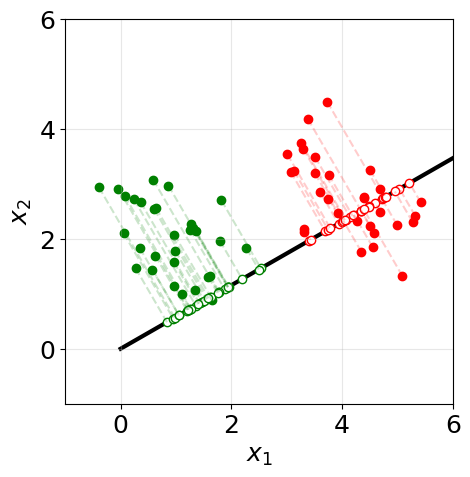

In [74]:
# 可视化数据集

# 创建画布
plt.figure(figsize=(5, 5))

# 绘制样本点
plt.scatter(x_0_sample[:, 0], x_0_sample[:, 1], color="g")
plt.scatter(x_1_sample[:, 0], x_1_sample[:, 1], color="r")

# 绘制投影点
plt.scatter(z_0[:, 0], z_0[:, 1], color="g", marker="o", facecolor="w")
plt.scatter(z_1[:, 0], z_1[:, 1], color="r", marker="o", facecolor="w")

# 绘制投影直线
if w[0] > w[1]:
    x_plot = np.linspace(0, 6)
    y_plot = w[1] / w[0] * x_plot
else:
    y_plot = np.linspace(0, 6)
    x_plot = w[0] / w[1] * y_plot
line, = plt.plot(x_plot, y_plot, color="k", lw=3)
line.zorder = -1

# 绘制投影虚线
x_plot = np.vstack([x_0_sample[:, 0], z_0[:, 0]])
y_plot = np.vstack([x_0_sample[:, 1], z_0[:, 1]])
plt.plot(x_plot, y_plot, color="g", ls="--", alpha=0.2)
x_plot = np.vstack([x_1_sample[:, 0], z_1[:, 0]])
y_plot = np.vstack([x_1_sample[:, 1], z_1[:, 1]])
plt.plot(x_plot, y_plot, color="r", ls="--", alpha=0.2)

# 美化细节
plt.grid(alpha=0.3)
plt.tick_params(labelsize=18)
plt.xlabel("$x_1$", size=18)
plt.ylabel("$x_2$", size=18)
plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.xticks([0, 2, 4, 6])
plt.yticks([0, 2, 4, 6])
plt.show()

In [83]:
@interact(
    theta=ipywidgets.FloatSlider(value=30, min=0, max=90, step=5, description="角度")
)
def plot(theta):
    # 角度制转弧度制
    theta = theta * np.pi / 180
    # 计算单位方向向量
    w = np.array([np.cos(theta), np.sin(theta)])

    # 计算投影后的结果
    z_0 = np.einsum("i,ji->j", w, x_0_sample)
    z_0 = np.einsum("i,j->ij", z_0, w)
    z_1 = np.einsum("i,ji->j", w, x_1_sample)
    z_1 = np.einsum("i,j->ij", z_1, w)
    
    # 计算目标函数值
    S_b = np.outer(mu_0 - mu_1, mu_0 - mu_1)
    S_w = sigma_0 + sigma_1
    J = np.dot(w, S_b @ w) / np.dot(w, S_w @ w)

    # 创建画布
    plt.figure(figsize=(5, 5))
    
    # 绘制样本点
    plt.scatter(x_0_sample[:, 0], x_0_sample[:, 1], color="g")
    plt.scatter(x_1_sample[:, 0], x_1_sample[:, 1], color="r")
    
    # 绘制投影点
    plt.scatter(z_0[:, 0], z_0[:, 1], color="g", marker="o", facecolor="w")
    plt.scatter(z_1[:, 0], z_1[:, 1], color="r", marker="o", facecolor="w")
    
    # 绘制投影直线
    if w[0] > w[1]:
        x_plot = np.linspace(0, 6)
        y_plot = w[1] / w[0] * x_plot
    else:
        y_plot = np.linspace(0, 6)
        x_plot = w[0] / w[1] * y_plot
    line, = plt.plot(x_plot, y_plot, color="k", lw=3)
    line.zorder = -1
    
    # 绘制投影虚线
    x_plot = np.vstack([x_0_sample[:, 0], z_0[:, 0]])
    y_plot = np.vstack([x_0_sample[:, 1], z_0[:, 1]])
    plt.plot(x_plot, y_plot, color="g", ls="--", alpha=0.2)
    x_plot = np.vstack([x_1_sample[:, 0], z_1[:, 0]])
    y_plot = np.vstack([x_1_sample[:, 1], z_1[:, 1]])
    plt.plot(x_plot, y_plot, color="r", ls="--", alpha=0.2)
    
    # 美化细节
    plt.grid(alpha=0.3)
    plt.tick_params(labelsize=18)
    plt.title(f"$J(w)$ = {J:.3f}")
    plt.xlabel("$x_1$", size=18)
    plt.ylabel("$x_2$", size=18)
    plt.xlim(-1, 6)
    plt.ylim(-1, 6)
    plt.xticks([0, 2, 4, 6])
    plt.yticks([0, 2, 4, 6])
    plt.show()

interactive(children=(FloatSlider(value=30.0, description='角度', max=90.0, step=5.0), Output()), _dom_classes=(…

## 根据公式计算理论最优解

In [93]:
# 最优解
# 注：一般不会直接通过求逆矩阵的方式计算，为了保证稳定性通常使用奇异值分解
w_opt = np.linalg.inv(S_w) @ (mu_0 - mu_1)
w_opt = w_opt / np.linalg.norm(w_opt) / np.sign(w_opt[0])
print(f"{w_opt = }")

# 计算目标函数值
S_b = np.outer(mu_0 - mu_1, mu_0 - mu_1)
S_w = sigma_0 + sigma_1
J_opt = np.dot(w_opt, S_b @ w_opt) / np.dot(w_opt, S_w @ w_opt)
print(f"{J_opt = }")

# 顺便计算此时的方向（角度）
theta = np.arctan2(w_opt[1], w_opt[0])
theta = theta / np.pi * 180
print(f"{theta = }°")

w_opt = array([0.82948808, 0.55852442])
J_opt = 19.0354809345713
theta = 33.9538125797961°
